# Captcha Solver
- Get Dataset
- Visualize Data
- Modify Data + Append more by transforming

### Download + read through + Visualize


In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("fournierp/captcha-version-2-images")
print("Path to dataset files:", path)

c:\Users\anhmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 17.4M/17.4M [00:02<00:00, 8.96MB/s]

Extracting files...


Path to dataset files: C:\Users\anhmi\.cache\kagglehub\datasets\fournierp\captcha-version-2-images\versions\2


In [50]:
import os
import numpy as np
import pandas as pd
DATA_FOLDER = path + "/samples"
ABSOLUTE_PATH = os.path.join(path, DATA_FOLDER)
print("Absolute path to dataset files:", ABSOLUTE_PATH)
print("Folders in dataset directory:", os.listdir(path))
print("Total files in dataset directory:", len(os.listdir(ABSOLUTE_PATH)))
print("Sample files in dataset directory:", os.listdir(ABSOLUTE_PATH)[:5])
print("5 first file label == the result of the image:", [file.split(".")[0] for file in os.listdir(ABSOLUTE_PATH)[:5]])

Absolute path to dataset files: C:\Users\anhmi\.cache\kagglehub\datasets\fournierp\captcha-version-2-images\versions\2/samples
Folders in dataset directory: ['samples']
Total files in dataset directory: 1071
Sample files in dataset directory: ['226md.png', '22d5n.png', '2356g.png', '23mdg.png', '23n88.png']
5 first file label == the result of the image: ['226md', '22d5n', '2356g', '23mdg', '23n88']


### Some Util

In [51]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
def get_label_from_file_name(fileName:str):
    return fileName.split(".")[0]

def show_samples(images: list, labels: list):
    size = math.ceil(math.sqrt(len(images)))
    row ,col = size ,size
    fig, axes = plt.subplots(row, col, figsize=(10, 5))
    for i in range(len(images)):
        img = mpimg.imread(images[i])
        x = i // col
        y = i % col
        axes[x, y].imshow(img,cmap='gray')
        axes[x, y].set_title(labels[i])
        axes[x, y].axis('off')
    plt.show()
    
def reset_plot():
    plt.clf()
    plt.cla()
    plt.close()
    


### Visualize

Sample file names: ['3x5fm.png', '3xcgg.png', '3xng6.png', '3ye2e.png', '3ygde.png', '3ym7f.png', '428b6.png', '42dw4.png', '42nxy.png', '42xpy.png', '43gey.png', '43mn5.png', '43p5d.png', '43xfe.png', '4433m.png', '445cc.png', '44c22.png', '44fyb.png', '44xe8.png', '44ype.png', '467d5.png', '46mbm.png', '4743p.png', '474ff.png', '478nx.png', '47e4p.png', '47m2b.png', '488de.png', '4b2pw.png', '4c8n8.png', '4cfw8.png', '4cn7b.png', '4d22m.png', '4dgf7.png', '4dw3w.png', '4egem.png']


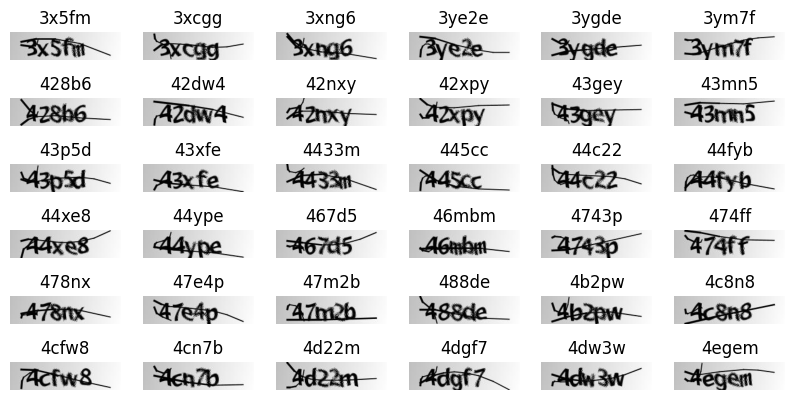

In [39]:
# take 36 samples
sample_images_file_name = os.listdir(ABSOLUTE_PATH)[100:100+36]
print("Sample file names:", sample_images_file_name)

sample_images = [os.path.join(ABSOLUTE_PATH, file_name) for file_name in sample_images_file_name]
sample_labels = [get_label_from_file_name(file_name) for file_name in sample_images_file_name]
max_file_name_length = max([len(file_name.split('.')[0]) for file_name in sample_images_file_name])
show_samples(sample_images, sample_labels)

### Get the shape and some meta like character

In [61]:
import string
import tensorflow as tf
import keras 

print(tf.__version__)
print(keras.__version__)
print("max file name length:", max_file_name_length)
ALL_CHARACTERS = string.ascii_lowercase + string.digits
print(ALL_CHARACTERS)
sample_image = keras.utils.load_img(sample_images[0], color_mode="grayscale") # PIL image
arr = keras.utils.img_to_array(sample_image)            # numpy array
print("Image shape:", arr.shape)
IMAGE_SHAPE = arr.shape # → (H, W, C)
PREDICT_SIZE = max_file_name_length

LABEL_DICT_INDEX =  {c: i for i, c in enumerate(ALL_CHARACTERS) }



2.21.0
3.13.2
max file name length: 5
abcdefghijklmnopqrstuvwxyz0123456789
Image shape: (50, 200, 1)


### Build the model
- Do some image transformation to extract the feature stuff 
- Go through some convolutional layer + Pooling -> to flatten 

In [41]:
def build_model_base():
    input = keras.layers.Input(shape=IMAGE_SHAPE)
    convo1 = keras.layers.Convolution2D(filters=8,kernel_size=(3,3),padding="same", activation="relu")
    pooling1 = keras.layers.MaxPool2D(pool_size=(2,2), padding="same") # reduce to (H/2, W/2) = 100 x 25
    convol2 = keras.layers.Convolution2D(filters=16,kernel_size=(3,3),padding="same", activation="relu")
    pooling2 = keras.layers.MaxPool2D(pool_size=(2,2), padding="same") # reduce to (H/4, W/4) = 50 x 13
    
    pipeline_up_to_flatten = pooling2(convol2(pooling1(convo1(input))))
    
    # flatten the image up to now to feed the dense layers
    flatten = keras.layers.Flatten()(pipeline_up_to_flatten)
    outputs = []
    for i in range(PREDICT_SIZE):
        dense1 = keras.layers.Dense(units=64, activation="relu"  )(flatten)
        output = keras.layers.Dense(units=len(ALL_CHARACTERS), activation="sigmoid")(dense1)
        outputs.append(output)

    model = keras.Model(inputs=input, outputs=outputs)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [42]:
model = build_model_base()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 200,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 50, 200,   │         80 │ input_layer_2[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 25, 100,   │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 25, 100,   │      1,168 │ max_pooling2d_4[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 13, 50,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 10400)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │    665,664 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │    665,664 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │    665,664 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │    665,664 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │    665,664 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 36)        │      2,340 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 36)        │      2,340 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 36)        │      2,340 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 36)        │      2,340 │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 36)        │      2,340 │ dense_33[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,341,268 (12.75 MB)

 Trainable params: 3,341,268 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
def get_dataset(img_folders: str) -> tuple[np.ndarray, list]:
    # return dataset and its labels
    X = []
    Y = []
    for img_name in os.listdir(img_folders):
        abs_img_path = os.path.join(img_folders, img_name)
        if not os.path.isfile(abs_img_path):
            continue
        # need to normalize the gray scale to be in the range [0, 1]
        image = keras.utils.load_img(abs_img_path, color_mode="grayscale")  # PIL image
        image = keras.utils.img_to_array(image) / 255.0  # normalize to [0, 1]
        label = get_label_from_file_name(img_name)
        X.append(image)
        Y.append(label)
    return np.array(X), Y



dataset = get_dataset(ABSOLUTE_PATH)
print("Dataset shape:", dataset[0].shape)
print("Dataset labels:", dataset[1][:5])
print("Image shape:", dataset[0][0].shape)
print("gray scale of the first 5 pixels in the first image (normalized):", dataset[0][0][-1][:5])


def create_label_one_hot_encoder(labels: list[str]) -> np.ndarray:
    # create a one hot encoder for the labels
    # the output is a numpy array of shape (len(labels), PREDICT_SIZE, len(ALL_CHARACTERS))
    # or (1071 img, 5 column represent the output, 36 rows represent the possible characters, each with a sigmoid output)
    result_encoded = []
    for i, label in enumerate(labels):
        encoded_label = np.zeros((PREDICT_SIZE, len(ALL_CHARACTERS)))
        for j, char in enumerate(label):
            char_index = LABEL_DICT_INDEX[char]
            encoded_label[j][char_index] = 1
        result_encoded.append(encoded_label)
    return np.array(result_encoded)

encoded_labels = create_label_one_hot_encoder(dataset[1])
print("Encoded labels shape:", encoded_labels.shape)
print("2 labels for the 2 first images:", encoded_labels[:2])


Dataset shape: (1070, 50, 200, 1)
Dataset labels: ['226md', '22d5n', '2356g', '23mdg', '23n88']
Image shape: (50, 200, 1)
gray scale of the first 5 pixels in the first image (normalized): [[0.7647059 ]
 [0.7647059 ]
 [0.7647059 ]
 [0.76862746]
 [0.76862746]]
Encoded labels shape: (1070, 5, 36)
2 labels for the 2 first images: [[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
   0. 0. 0. 0. 0. 1. 0.